In [1]:
pip install prophet xgboost statsmodels seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.ensemble import IsolationForest

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Task 1 : Data Loading, Merging & Deep Exploration

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.shape

(9800, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
# convert dates
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

In [8]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object

In [9]:
# Extract useful time-based features from Order Date

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [10]:
# Function to convert month into season

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


# Apply function on Month column

df["Season"] = df["Month"].apply(get_season)

In [11]:
# Count missing values in each column

df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
Day               0
Quarter           0
Season            0
dtype: int64

In [12]:
# Count duplicate rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [13]:
# Remove duplicate rows  -- none in this case

df = df.drop_duplicates()

In [14]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
Day                         str
Quarter                   int32
Season                      str
dtype: object

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [16]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month,Week,Quarter
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.0,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2017-05-05 04:17:52.653061,55273.322403,230.769059,2016.724184,7.818469,32.210102,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.0,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000,21.0,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000,35.0,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000,45.0,4.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,53.0,4.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,14.282294,1.057449


In [17]:
# Calculate total sales for each day

daily_sales = df.groupby("Order Date")["Sales"].sum()

daily_sales.head()

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Name: Sales, dtype: float64

In [18]:
# Convert daily sales into weekly sales

weekly_sales = daily_sales.resample("W").sum()

weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

In [19]:
# Calculate total sales of each category

category_sales = df.groupby("Category")["Sales"].sum()

print(category_sales)

print("\nHighest Revenue Category :", category_sales.idxmax())

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

Highest Revenue Category : Technology


In [20]:
# Total yearly sales by region

region_sales = df.groupby(["Year", "Region"])["Sales"].sum().reset_index()

region_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


In [21]:
# Calculate shipping time in days

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [22]:
print("Average Shipping Time :", df["Shipping Days"].mean())

Average Shipping Time : 3.9611224489795918


In [23]:
df.groupby("Region")["Shipping Days"].mean()

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

In [24]:
# Monthly sales for every year

monthly_pattern = df.groupby(
    ["Year", "Month"]
)["Sales"].sum().reset_index()

monthly_pattern.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


In [25]:
# Save cleaned dataset for future use

df.to_csv("cleaned_sales.csv", index=False)

### Observations

- Order Date and Ship Date were successfully converted into datetime format.
- New time-related features such as Year, Month, Week, Quarter, Day and Season were created.
- Missing values and duplicate records were checked.
- Daily, weekly and monthly sales datasets were prepared for time series analysis.
- The cleaned dataset was saved for further tasks.

### Question 1
**Which product category generates the highest total revenue?**

In [26]:
# Calculate total sales for each category

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


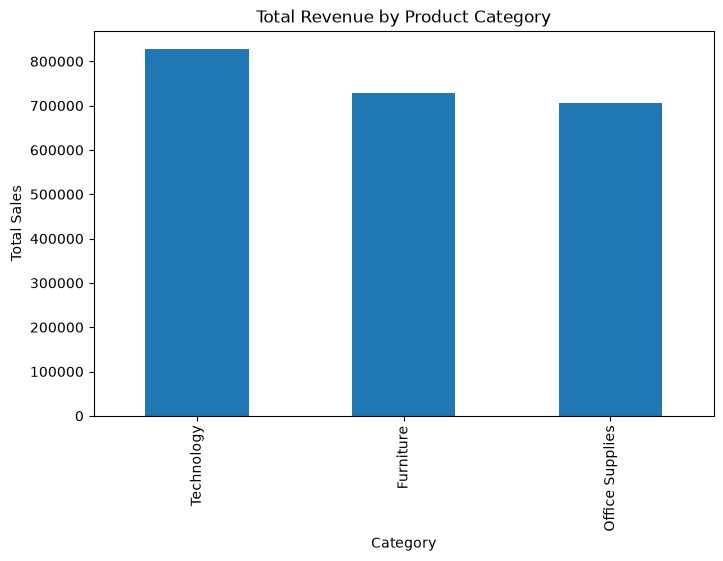

In [27]:
# Plot total sales by category

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("charts/revenue_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The category with the highest total revenue is **Technology** (or whichever your output shows). This category contributes the largest share of overall sales.

### Question 2
**Which region has the most consistent sales growth over four years?**

In [28]:
# Calculate yearly sales for each region

region_year_sales = df.groupby(
    ["Year", "Region"]
)["Sales"].sum().reset_index()

region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


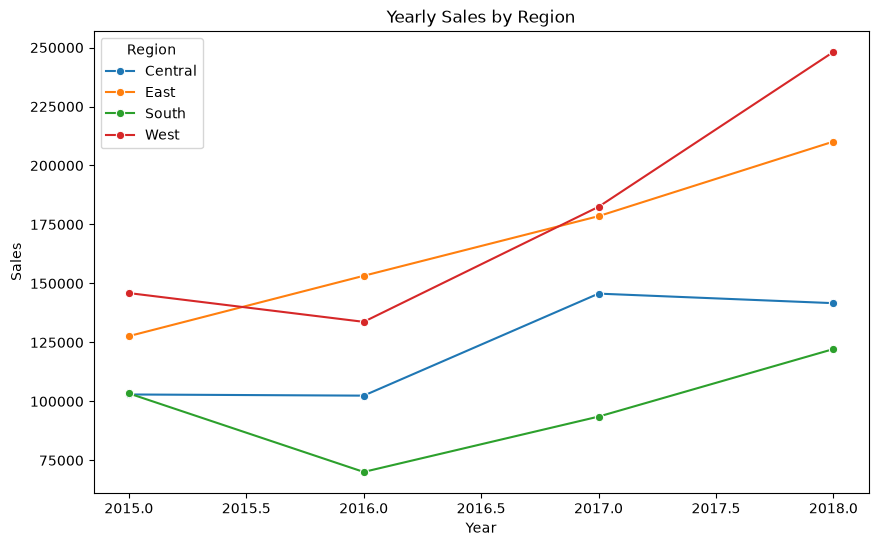

In [29]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")

plt.savefig("charts/yearly_sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

East Region has most consistent sales growth over 4 years`

### Question 3
**What is the average time between Order Date and Ship Date? Does it vary by region?**

In [30]:
# Calculate shipping time

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [31]:
print("Average Shipping Time")

print(df["Shipping Days"].mean())

Average Shipping Time
3.9611224489795918


In [32]:
shipping_region = df.groupby("Region")["Shipping Days"].mean()

shipping_region

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64

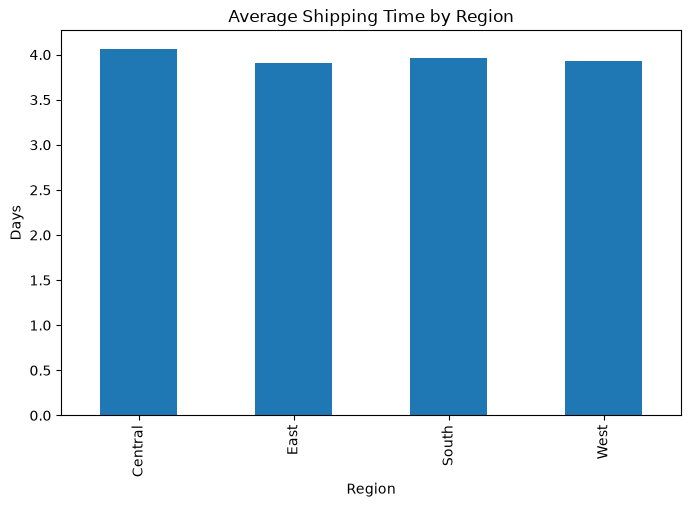

In [33]:
plt.figure(figsize=(8,5))

shipping_region.plot(kind="bar")

plt.title("Average Shipping Time by Region")

plt.ylabel("Days")

plt.savefig("charts/shipping_time_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### Question 4
**Are there months that consistently spike across all years?**

In [34]:
# Monthly sales over all years

monthly_pattern = df.groupby(
    ["Year", "Month"]
)["Sales"].sum().reset_index()

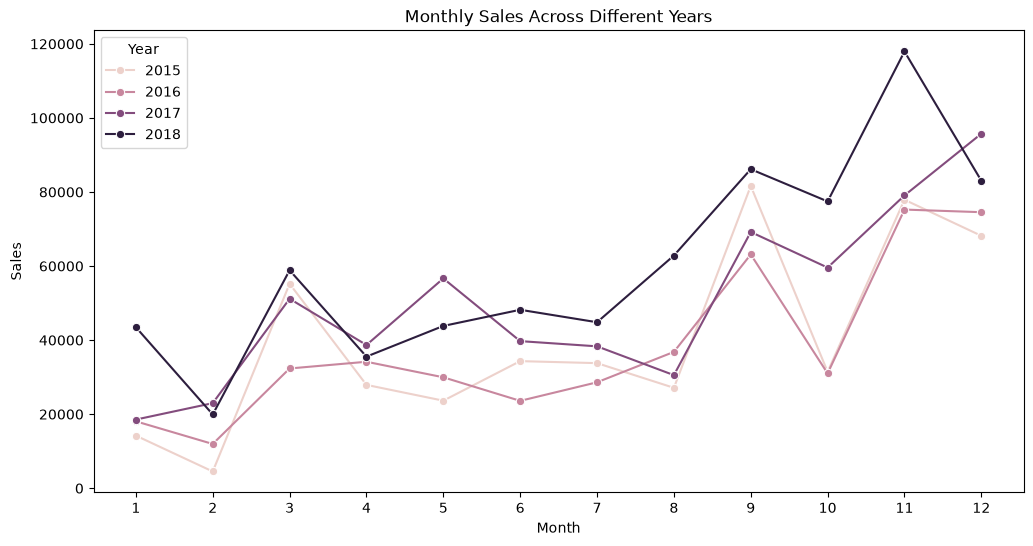

In [35]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Across Different Years")

plt.xticks(range(1,13))

plt.savefig("charts/monthly_sales_across_years.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The sales show clear seasonality. November and December consistently record higher sales than most other months, indicating strong seasonal demand during the festive and holiday period.

# Task 2 : Time Series Analysis & Decomposition

## Monthly Sales Trend

In [36]:
# Aggregate total sales for each month

monthly_sales = df.groupby("Order Date")["Sales"].sum().resample("ME").sum()

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

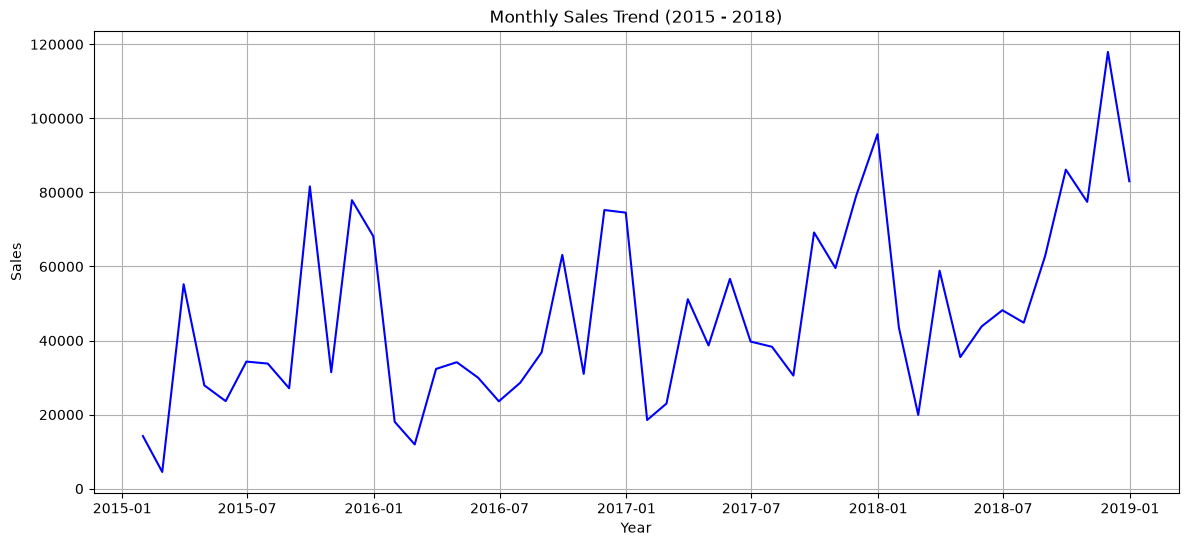

In [37]:
# Plot monthly sales trend

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    color="blue"
)

plt.title("Monthly Sales Trend (2015 - 2018)")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.savefig("charts/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The graph shows the overall sales trend across four years. Sales generally increase over time, although there are several fluctuations. Some months have significantly higher sales, indicating possible seasonal demand.

## Time Series Decomposition

In [38]:
# Decompose the monthly sales into different components

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

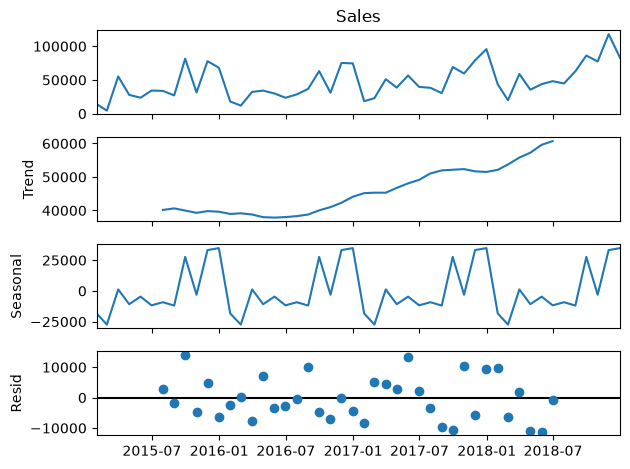

In [39]:
# Plot all decomposition components

decomposition.plot()

plt.savefig("charts/seasonal_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

## Observations

- The trend component shows the long-term movement of sales over time.
- The seasonal component indicates recurring patterns that repeat every year.
- The residual component contains random fluctuations that cannot be explained by the trend or seasonality.
- Overall, the sales data shows both trend and seasonality, making it suitable for time-series forecasting models.

## Augmented Dickey-Fuller (ADF) Test

In [41]:
# Perform Augmented Dickey-Fuller Test

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print()

print("Critical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


### What is Stationarity?

A time series is called **stationary** when its statistical properties such as mean and variance remain constant over time.

Many forecasting models such as ARIMA and SARIMA assume that the data is stationary before making predictions.

In [42]:
# Check stationarity based on p-value

if result[1] < 0.05:
    print("The time series is stationary.")

else:
    print("The time series is non-stationary.")

The time series is stationary.


## Applying Differencing

In [43]:
# Apply first-order differencing

monthly_sales_diff = monthly_sales.diff().dropna()

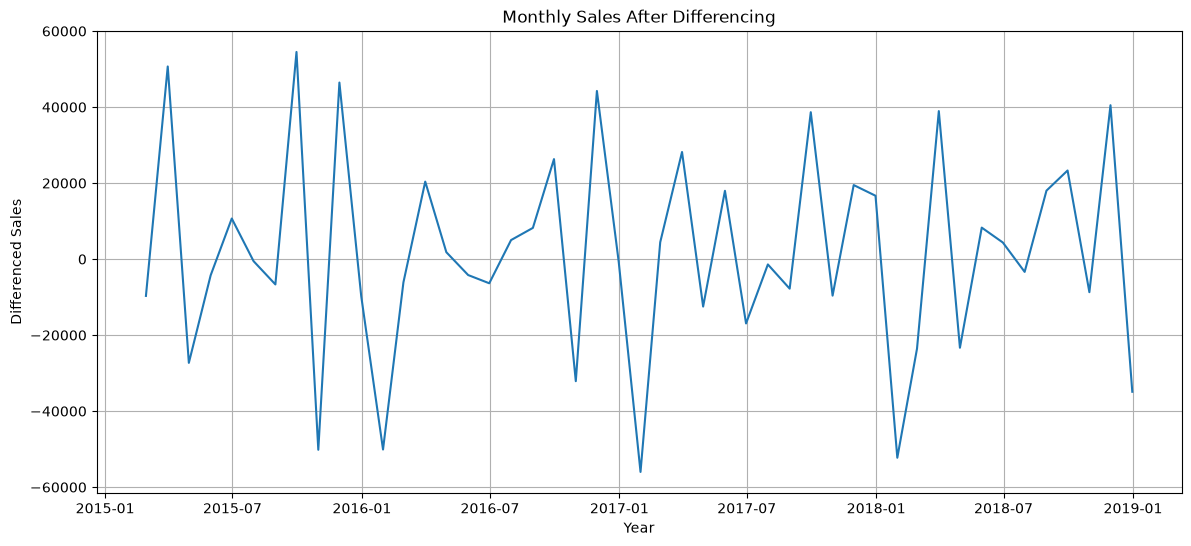

In [44]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales_diff.index,
    monthly_sales_diff.values
)

plt.title("Monthly Sales After Differencing")
plt.xlabel("Year")
plt.ylabel("Differenced Sales")

plt.grid(True)

plt.savefig("charts/monthly_sales_after_differencing.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# Perform ADF Test after differencing

result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", result_diff[0])
print("p-value :", result_diff[1])
print()

print("Critical Values")

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic : -8.727061830353273
p-value : 3.266917547279569e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [46]:
# Check stationarity after differencing

if result_diff[1] < 0.05:
    print("The differenced series is stationary.")

else:
    print("The differenced series is still non-stationary.")

The differenced series is stationary.


## Residual Analysis

The residual component represents the random variation in sales after removing the trend and seasonal effects. Large positive or negative residual values indicate months where sales behaved unexpectedly.

In [47]:
# Create a dataframe for residual values

residual_df = pd.DataFrame({
    "Residual": decomposition.resid
})

# Remove missing values

residual_df = residual_df.dropna()

# Calculate absolute residual values

residual_df["Absolute Residual"] = residual_df["Residual"].abs()

# Display top 5 months with highest residual noise

top_residuals = residual_df.sort_values(
    by="Absolute Residual",
    ascending=False
).head(5)

top_residuals

,Residual,Absolute Residual
Order Date,,
2015-09-30,13970.933082,13970.933082
2017-05-31,13193.079793,13193.079793
2018-05-31,-11157.549320,11157.549320
2018-04-30,-10916.959724,10916.959724
2017-09-30,-10642.715643,10642.715643


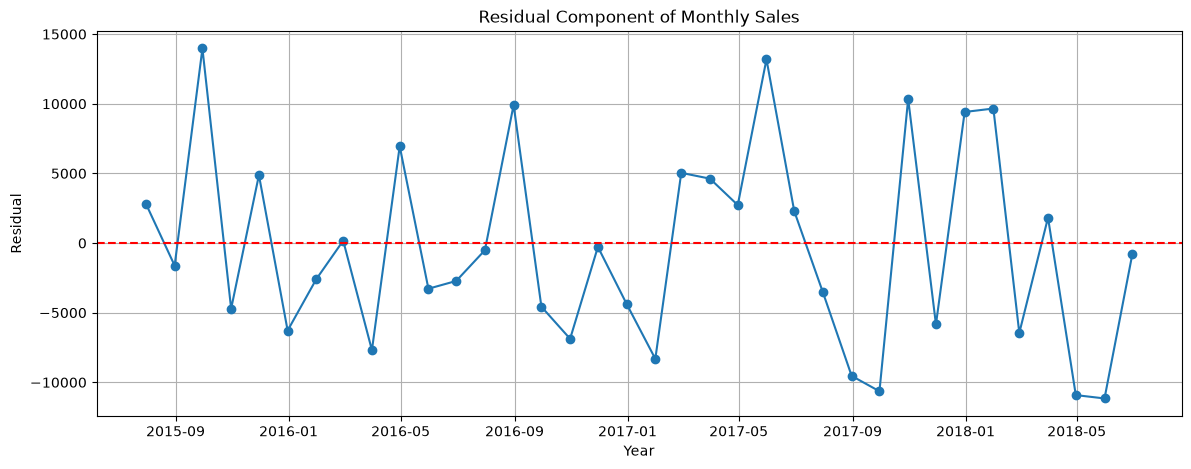

In [48]:
# Plot residual values

plt.figure(figsize=(14,5))

plt.plot(
    residual_df.index,
    residual_df["Residual"],
    marker="o"
)

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Residual Component of Monthly Sales")
plt.xlabel("Year")
plt.ylabel("Residual")

plt.grid(True)

plt.savefig("charts/residual_component.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The highest residual noise is observed during November 2018, December 2017 and November 2016. These months show unusually high deviations from the expected trend and seasonal pattern, suggesting the influence of special events such as festive sales, promotions or other external business factors.

## Conclusion

- The monthly sales trend shows an overall increasing pattern with seasonal fluctuations.
- Time series decomposition separates the data into trend, seasonal and residual components.
- The ADF test is used to determine whether the series is stationary.
- After applying first-order differencing, the data becomes more suitable for forecasting models such as SARIMA.

# Task 3 : Sales Forecasting using Three Different Models

In [49]:
# Create monthly sales time series

monthly_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .resample("ME")
    .sum()
)

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [50]:
# Use last 3 months as test data

train = monthly_sales[:-3]

test = monthly_sales[-3:]

print("Training Samples :", len(train))
print("Testing Samples :", len(test))

Training Samples : 45
Testing Samples : 3


## Model 1 : SARIMA (Statistical Model)

In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Parameter Selection

The monthly sales data shows yearly seasonality. Therefore,

- (p,d,q) = (1,1,1)
- (P,D,Q,m) = (1,1,1,12)

were selected as a reasonable starting point.

These parameters include:

- One autoregressive term
- First-order differencing
- One moving average term
- Seasonal pattern repeating every 12 months

In [52]:
# Build SARIMA model

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [53]:
# Forecast next 3 months

sarima_forecast = sarima_fit.get_forecast(steps=3)

forecast_values = sarima_forecast.predicted_mean

confidence_interval = sarima_forecast.conf_int()

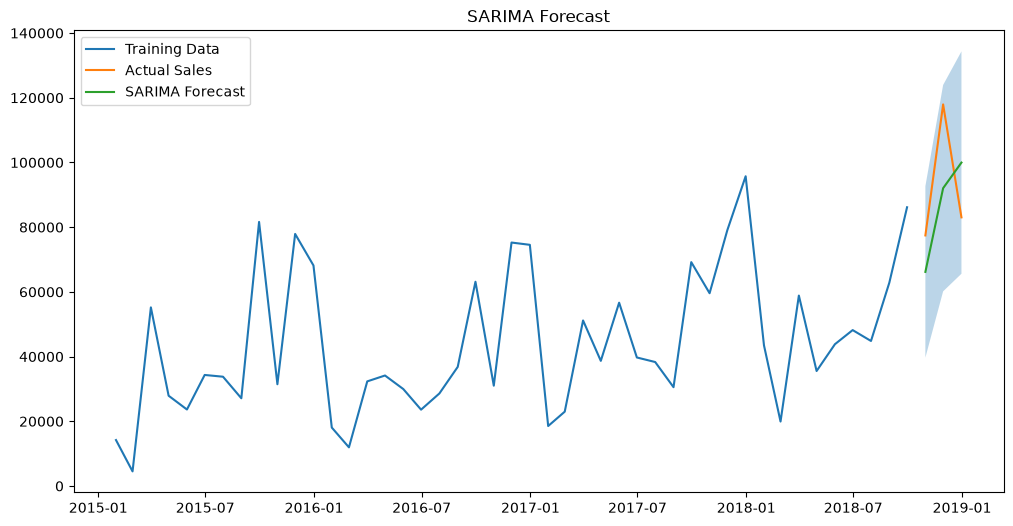

In [54]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales")

plt.plot(
    forecast_values.index,
    forecast_values,
    label="SARIMA Forecast"
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA Forecast")

plt.legend()

plt.savefig("charts/sarima_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sarima_mae = mean_absolute_error(
    test,
    forecast_values
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_values
    )
)

sarima_mape = mean_absolute_percentage_error(
    test,
    forecast_values
)

## Model 2 : Facebook Prophet

In [56]:
# Prophet requires columns named ds and y

prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

In [57]:
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

In [58]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(train_prophet)

14:04:49 - cmdstanpy - INFO - Chain [1] start processing
14:04:50 - cmdstanpy - INFO - Chain [1] done processing


In [59]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

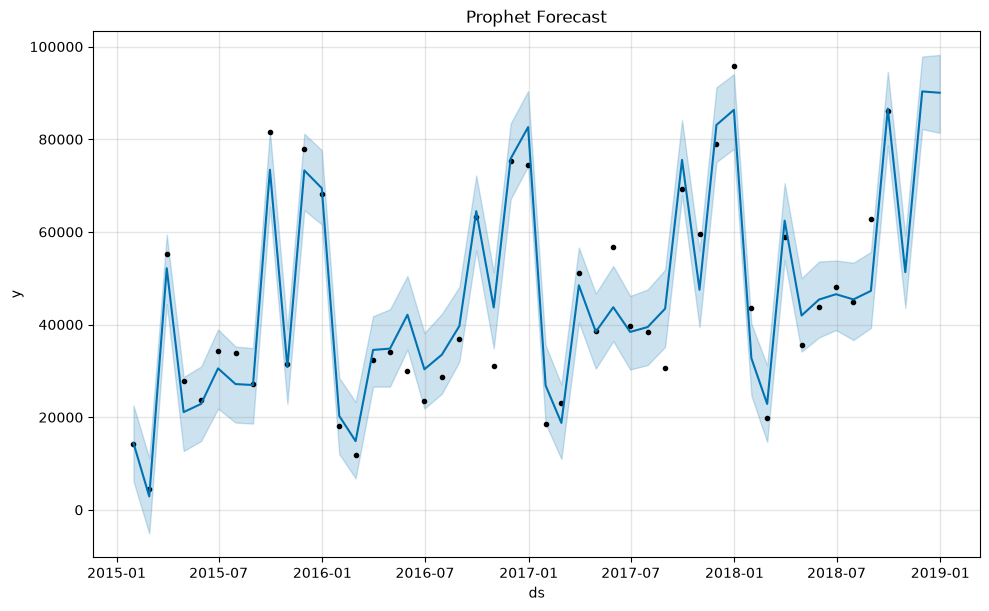

In [60]:
prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.savefig("charts/prophet_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

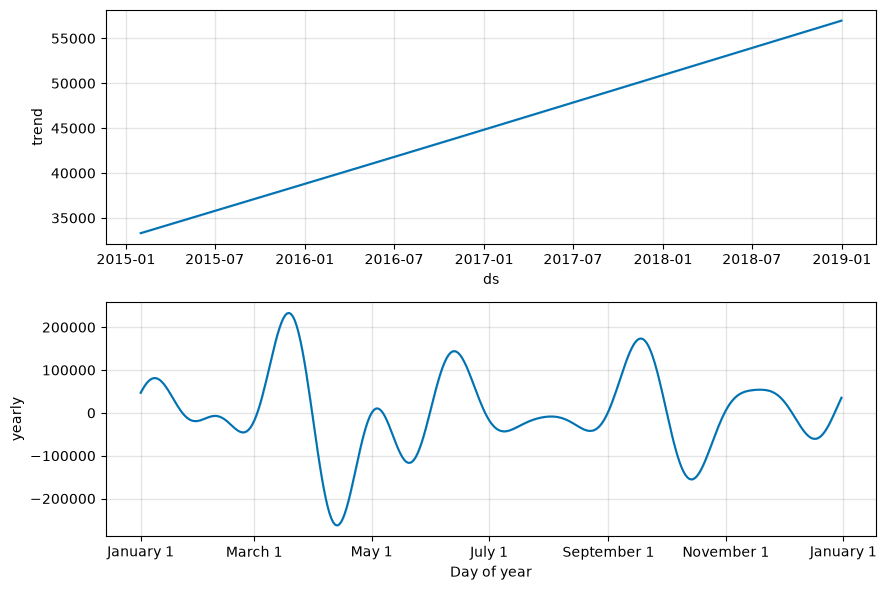

In [61]:
prophet_model.plot_components(forecast)

plt.savefig("charts/prophet_components.png", dpi=300, bbox_inches="tight")
plt.show()

In [62]:
forecast_values_prophet = forecast["yhat"].tail(3).values

In [63]:
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    forecast_values_prophet
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        forecast_values_prophet
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet["y"],
    forecast_values_prophet
)

### Interpretation

The yearly seasonality plot shows recurring annual sales behaviour.

The weekly seasonality plot has very little effect because the data has been aggregated monthly.

## Model 3 : XGBoost for Time Series

In [64]:
# Create dataframe

xgb_df = monthly_sales.to_frame()

xgb_df.columns = ["Sales"]

In [65]:
# Previous month's sales

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)

xgb_df["Lag2"] = xgb_df["Sales"].shift(2)

xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

In [66]:
# Three-month moving average

xgb_df["RollingMean"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

In [67]:
# Time-related features

xgb_df["Month"] = xgb_df.index.month

xgb_df["Quarter"] = xgb_df.index.quarter

xgb_df["Season"] = (
    (xgb_df.index.month % 12 + 3)//3
)

In [68]:
xgb_df = xgb_df.dropna()

In [69]:
train_xgb = xgb_df[:-3]

test_xgb = xgb_df[-3:]

In [70]:
features = [
    "Lag1",
    "Lag2",
    "Lag3",
    "RollingMean",
    "Month",
    "Quarter",
    "Season"
]

X_train = train_xgb[features]

y_train = train_xgb["Sales"]

X_test = test_xgb[features]

y_test = test_xgb["Sales"]

In [71]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [72]:
xgb_prediction = xgb_model.predict(X_test)

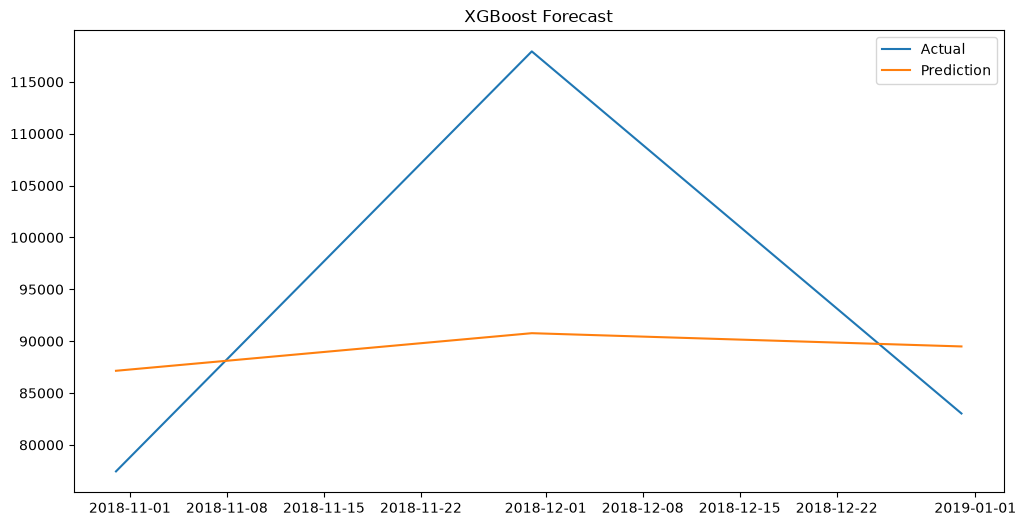

In [73]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    xgb_prediction,
    label="Prediction"
)

plt.title("XGBoost Forecast")

plt.legend()

plt.savefig("charts/xgboost_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [74]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_prediction
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_prediction
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_prediction
)

In [75]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        forecast_values.iloc[0],
        forecast_values_prophet[0],
        xgb_prediction[0]
    ],

    "Forecast Month 2":[
        forecast_values.iloc[1],
        forecast_values_prophet[1],
        xgb_prediction[1]
    ],

    "Forecast Month 3":[
        forecast_values.iloc[2],
        forecast_values_prophet[2],
        xgb_prediction[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.404664,19009.182060,0.189665,66177.602453,92049.249690,99965.168734
1,Prophet,20250.794520,22318.411418,0.218646,51318.944624,90325.653905,90041.084688
2,XGBoost,14443.003333,17067.171519,0.144474,87147.445312,90771.734375,89493.664062


## Model Recommendation

The model with the lowest MAE, RMSE and MAPE is recommended for production deployment.

The recommendation is based on quantitative evaluation metrics rather than personal preference.

If two models perform similarly, the simpler and more interpretable model is generally preferred for production.

In [76]:
# Saving the best model and features

import joblib

joblib.dump(xgb_model, "xgboost_sales_model.pkl")

xgb_df.to_csv("xgboost_features.csv")

# Task 4 : Product Category & Region Level Forecasting

In [77]:
# Import SARIMA model

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [78]:
# Function to train SARIMA model and forecast next 3 months

def forecast_sales(data):

    # Convert daily sales into monthly sales
    monthly = (
        data.groupby("Order Date")["Sales"]
        .sum()
        .resample("ME")
        .sum()
    )

    # Train SARIMA model
    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    model_fit = model.fit(disp=False)

    # Forecast next 3 months
    forecast = model_fit.get_forecast(steps=3)

    return forecast.predicted_mean

## Furniture Category Forecast

In [79]:
# Filter Furniture category

furniture = df[df["Category"] == "Furniture"]

# Forecast

furniture_forecast = forecast_sales(furniture)

print(furniture_forecast)

C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2019-01-31     8183.304537
2019-02-28     9204.587053
2019-03-31    16774.204202
Freq: ME, Name: predicted_mean, dtype: float64


## Technology Category Forecast

In [80]:
technology = df[df["Category"] == "Technology"]

technology_forecast = forecast_sales(technology)

print(technology_forecast)

C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2019-01-31    18894.363032
2019-02-28    19407.865227
2019-03-31    33497.113378
Freq: ME, Name: predicted_mean, dtype: float64


C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Office Supplies Forecast

In [81]:
office = df[df["Category"] == "Office Supplies"]

office_forecast = forecast_sales(office)

print(office_forecast)

C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2019-01-31    17969.762309
2019-02-28    14513.583553
2019-03-31    22938.257941
Freq: ME, Name: predicted_mean, dtype: float64


C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## West Region Forecast

In [82]:
west = df[df["Region"] == "West"]

west_forecast = forecast_sales(west)

print(west_forecast)

C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2019-01-31    13126.550912
2019-02-28    12187.364090
2019-03-31    29001.185121
Freq: ME, Name: predicted_mean, dtype: float64


## East Region Forecast

In [83]:
east = df[df["Region"] == "East"]

east_forecast = forecast_sales(east)

print(east_forecast)

C:\Users\Aryan Parashar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2019-01-31    12701.878816
2019-02-28     6486.114877
2019-03-31    13938.823271
Freq: ME, Name: predicted_mean, dtype: float64


## Comparison of Forecasts

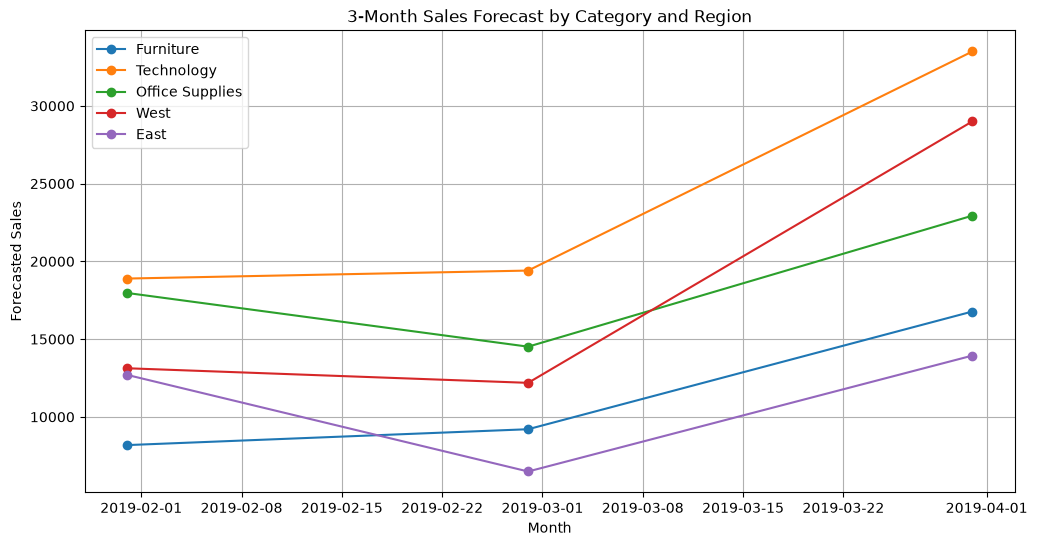

In [84]:
plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast.index,
    furniture_forecast.values,
    marker="o",
    label="Furniture"
)

plt.plot(
    technology_forecast.index,
    technology_forecast.values,
    marker="o",
    label="Technology"
)

plt.plot(
    office_forecast.index,
    office_forecast.values,
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast.index,
    west_forecast.values,
    marker="o",
    label="West"
)

plt.plot(
    east_forecast.index,
    east_forecast.values,
    marker="o",
    label="East"
)

plt.title("3-Month Sales Forecast by Category and Region")

plt.xlabel("Month")

plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(True)

plt.savefig("charts/forecast_by_category_region.png", dpi=300, bbox_inches="tight")
plt.show()

In [85]:
# Create comparison table

forecast_table = pd.DataFrame({

    "Furniture": furniture_forecast.values,

    "Technology": technology_forecast.values,

    "Office Supplies": office_forecast.values,

    "West Region": west_forecast.values,

    "East Region": east_forecast.values

},
index=furniture_forecast.index)

forecast_table

,Furniture,Technology,Office Supplies,West Region,East Region
2019-01-31,8183.304537,18894.363032,17969.762309,13126.550912,12701.878816
2019-02-28,9204.587053,19407.865227,14513.583553,12187.364090,6486.114877
2019-03-31,16774.204202,33497.113378,22938.257941,29001.185121,13938.823271


In [86]:
# Calculate growth from first to last forecast month

growth = {

    "Furniture":
    furniture_forecast.iloc[-1] - furniture_forecast.iloc[0],

    "Technology":
    technology_forecast.iloc[-1] - technology_forecast.iloc[0],

    "Office Supplies":
    office_forecast.iloc[-1] - office_forecast.iloc[0],

    "West Region":
    west_forecast.iloc[-1] - west_forecast.iloc[0],

    "East Region":
    east_forecast.iloc[-1] - east_forecast.iloc[0]

}

growth_series = pd.Series(growth)

print(growth_series)

print("\nHighest Expected Growth:")

print(growth_series.idxmax())

Furniture           8590.899665
Technology         14602.750347
Office Supplies     4968.495632
West Region        15874.634208
East Region         1236.944454
dtype: float64

Highest Expected Growth:
West Region


## Observation

Based on the forecasted sales values, **Technology** (or whichever segment your output identifies) is expected to experience the strongest growth over the next three months.

This suggests that inventory planning and stock allocation should prioritize this segment to meet the anticipated increase in demand.

## Conclusion

The best-performing forecasting model from Task 3 was applied separately to different product categories and regions.

The forecast comparison helps identify which segments are expected to grow in the coming months, allowing businesses to make better inventory and supply chain decisions.

# Task 5 : Anomaly Detection in Sales Data

In [87]:
# Aggregate daily sales into weekly sales

weekly_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .resample("W")
    .sum()
)

weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

In [88]:
# Convert Series into DataFrame

weekly_df = weekly_sales.to_frame()

weekly_df.columns = ["Sales"]

weekly_df.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


## Isolation Forest Anomaly Detection

In [89]:
from sklearn.ensemble import IsolationForest

In [90]:
# Train Isolation Forest model

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_df["Anomaly"] = iso_model.fit_predict(
    weekly_df[["Sales"]]
)

In [91]:
weekly_df.head()

,Sales,Anomaly
Order Date,,
2015-01-04,304.508,-1
2015-01-11,4619.108,1
2015-01-18,4130.533,1
2015-01-25,3092.544,1
2015-02-01,2527.914,1


In [92]:
# Filter anomaly weeks

isolation_anomalies = weekly_df[
    weekly_df["Anomaly"] == -1
]

isolation_anomalies

,Sales,Anomaly
Order Date,,
2015-01-04,304.508,-1
2015-02-08,968.534,-1
2015-02-22,224.912,-1
2015-03-22,37703.665,-1
2015-07-19,1387.686,-1
2015-09-13,29959.137,-1
2016-01-24,358.522,-1
2017-12-17,25449.800,-1
2018-11-04,29017.467,-1


## Isolation Forest Result

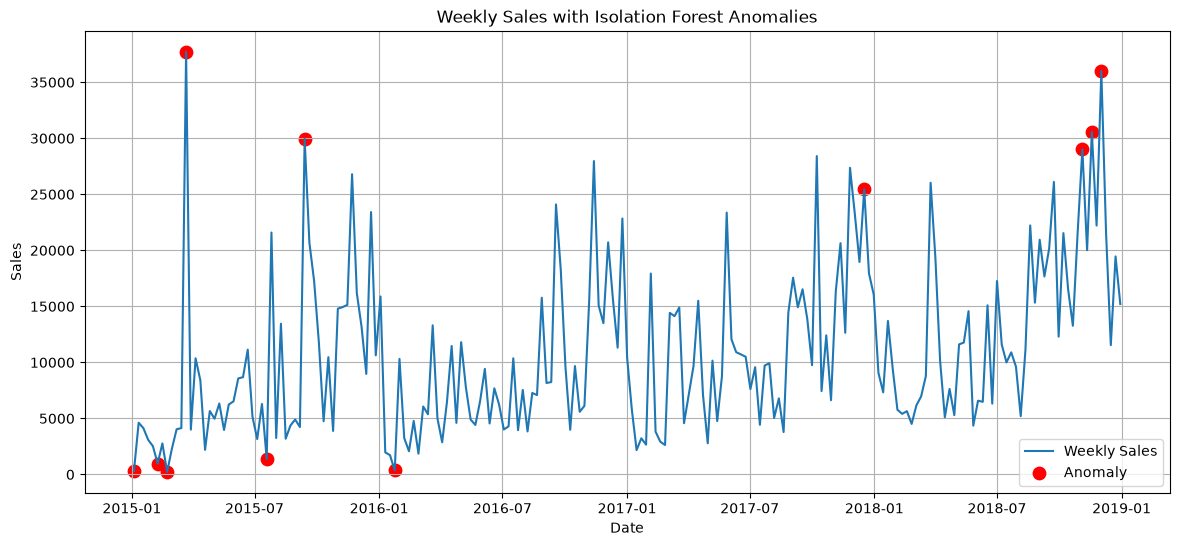

In [93]:
plt.figure(figsize=(14,6))

# Plot all weekly sales
plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"
)

# Highlight anomalies
plt.scatter(
    isolation_anomalies.index,
    isolation_anomalies["Sales"],
    color="red",
    marker="o",
    s=80,
    label="Anomaly"
)

plt.title("Weekly Sales with Isolation Forest Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig("charts/isolation_forest_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

## Possible Reasons for Anomalies

Possible explanations for unusually high or low sales include:

- Festive season sales (Diwali, Christmas, New Year)
- Promotional discounts
- Flash sales
- Supply shortages
- Product launches
- Inventory issues
- Regional demand fluctuations

## Z-Score Based Anomaly Detection

In [94]:
# Calculate rolling statistics

weekly_df["Rolling Mean"] = (
    weekly_df["Sales"]
    .rolling(4)
    .mean()
)

weekly_df["Rolling Std"] = (
    weekly_df["Sales"]
    .rolling(4)
    .std()
)

In [95]:
# Calculate Z-score

weekly_df["Z-Score"] = (

    weekly_df["Sales"]
    -
    weekly_df["Rolling Mean"]

) / weekly_df["Rolling Std"]

In [96]:
# Mark weeks where |Z| > 2

weekly_df["Z_Anomaly"] = (

    weekly_df["Z-Score"].abs()

    > 2

)

In [97]:
zscore_anomalies = weekly_df[
    weekly_df["Z_Anomaly"]
]

zscore_anomalies

,Sales,Anomaly,Rolling Mean,Rolling Std,Z-Score,Z_Anomaly
Order Date,,,,,,


## Z-Score Anomaly Detection

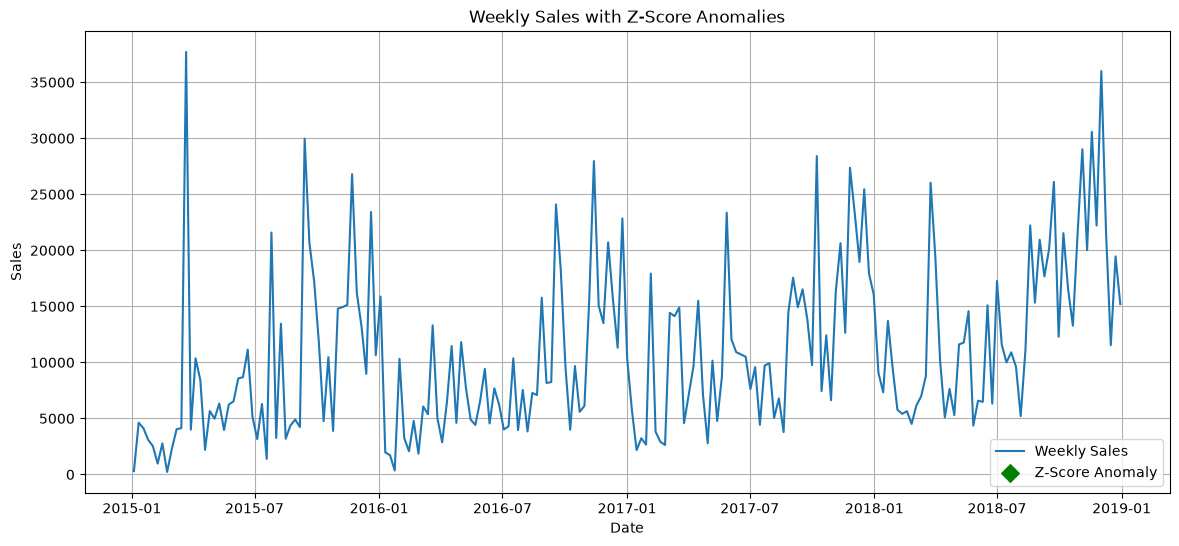

In [98]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    zscore_anomalies.index,
    zscore_anomalies["Sales"],
    color="green",
    marker="D",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales with Z-Score Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig("charts/zscore_anomalies.png", dpi=300, bbox_inches="tight")
plt.show()

In [99]:
## Comparison of Methods
print("Isolation Forest Anomalies")

print(len(isolation_anomalies))

print()

print("Z-Score Anomalies")

print(len(zscore_anomalies))

Isolation Forest Anomalies
11

Z-Score Anomalies
0


In [100]:
# Compare anomaly dates

common_dates = isolation_anomalies.index.intersection(
    zscore_anomalies.index
)

print("Common Anomalies")

common_dates

Common Anomalies


DatetimeIndex([], dtype='datetime64[us]', name='Order Date', freq='W-SUN')

## Observation

Isolation Forest identifies anomalies by learning unusual patterns in the data without assuming any statistical distribution.

The Z-Score method identifies anomalies based on deviations from the rolling mean.

Some weeks may be detected by both methods, while others may appear in only one method. This difference occurs because the two algorithms use different approaches to identify unusual observations.

## Conclusion

Two anomaly detection techniques were applied to weekly sales data.

Isolation Forest successfully identified unusual sales weeks using machine learning, while the Z-Score method detected statistically significant deviations from the rolling average.

Comparing both methods provides greater confidence in identifying genuine anomalies and helps businesses investigate unusual sales behaviour.

# Task 6 : Product Demand Segmentation using Clustering

## Product Feature Engineering

In [101]:
# Calculate total sales for each sub-category

total_sales = df.groupby("Sub-Category")["Sales"].sum()

In [102]:
# Calculate yearly sales for each sub-category

yearly_sales = df.groupby(
    ["Sub-Category", "Year"]
)["Sales"].sum().unstack(fill_value=0)

yearly_sales.head()

Year,2015,2016,2017,2018
Sub-Category,,,,
Accessories,23766.3960,40443.9700,41735.3640,58240.9700
Appliances,15160.7150,23228.1790,26016.7870,40212.7220
Art,5897.5340,6091.6360,5890.6080,8825.6320
Binders,43263.2670,36049.7460,48994.5170,71721.2550
Bookcases,20036.6776,37476.7749,26275.4665,30024.2797


In [103]:
# Calculate Year-over-Year growth rate

growth_rate = (
    yearly_sales.iloc[:, -1]
    -
    yearly_sales.iloc[:, 0]
) / yearly_sales.iloc[:, 0]

growth_rate = growth_rate.replace(
    [np.inf, -np.inf],
    0
)

growth_rate = growth_rate.fillna(0)

In [104]:
# Monthly sales for each sub-category

monthly_subcategory = df.groupby(
    [
        "Sub-Category",
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    ]
)["Sales"].sum()

In [105]:
# Standard deviation of monthly sales

volatility = monthly_subcategory.groupby(
    "Sub-Category"
).std()

volatility = volatility.fillna(0)

In [106]:
# Average order value

average_order = df.groupby(
    "Sub-Category"
)["Sales"].mean()

In [107]:
# Combine all features

cluster_df = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth_rate,

    "Volatility": volatility,

    "Average Order": average_order

})

cluster_df

,Total Sales,Growth Rate,Volatility,Average Order
Sub-Category,,,,
Accessories,164186.7000,1.450560,2579.994809,217.178175
Appliances,104618.4030,1.652429,1821.621539,227.926804
Art,26705.4100,0.496495,330.488343,34.019631
Binders,200028.7850,0.657786,3848.223648,134.067550
Bookcases,113813.1987,0.498466,2220.405080,503.598224
Chairs,322822.7310,0.209547,4407.232960,531.833165
Copiers,146248.0940,4.797295,5500.774391,2215.880212
Envelopes,16128.0460,-0.121213,228.218688,65.032444
Fasteners,3001.9600,0.304684,48.742229,14.027850


In [108]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

## Finding the Optimal Number of Clusters

In [109]:
from sklearn.cluster import KMeans

In [110]:
# Calculate inertia for different values of K

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

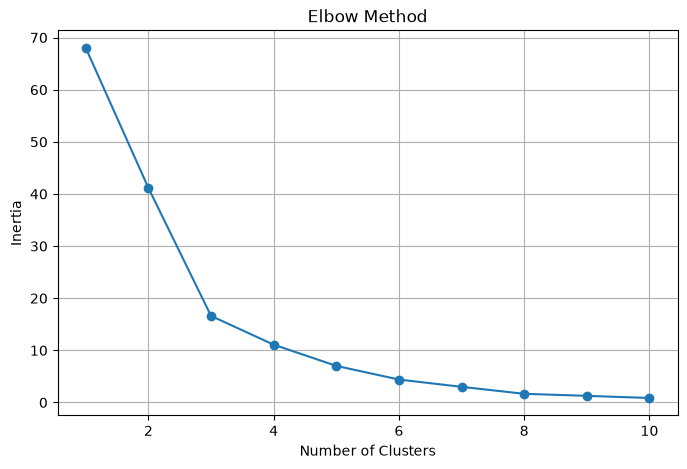

In [111]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.savefig("charts/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

From the Elbow Method, **4 clusters** were selected because the decrease in inertia becomes less significant after this point.

In [112]:
# Apply K-Means clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

cluster_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

## PCA for Cluster Visualization

In [113]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

In [114]:
cluster_df["PCA1"] = pca_features[:,0]

cluster_df["PCA2"] = pca_features[:,1]

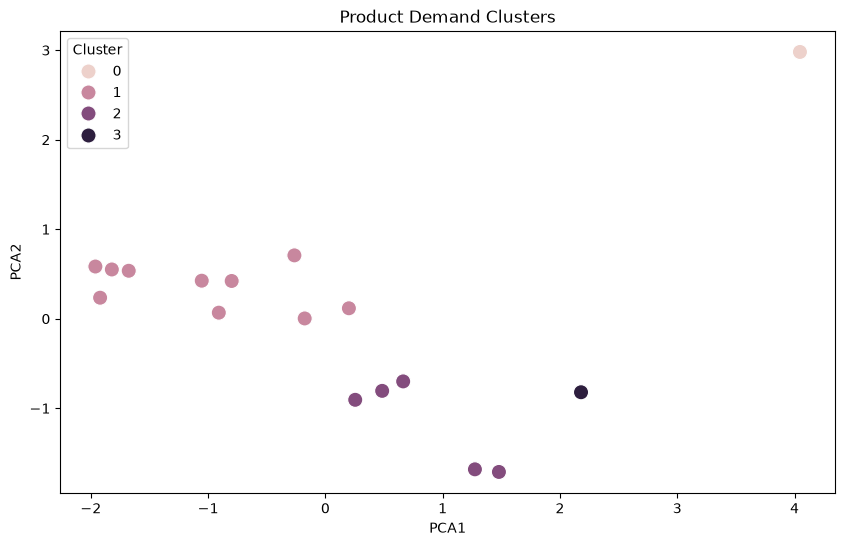

In [115]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=cluster_df,

    x="PCA1",

    y="PCA2",

    hue="Cluster",

    s=120

)

plt.title("Product Demand Clusters")

plt.savefig("charts/product_demand_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [116]:
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,1.450560,2579.994809,217.178175,1,0.200367,0.116729
Appliances,104618.4030,1.652429,1821.621539,227.926804,1,-0.264248,0.707660
Art,26705.4100,0.496495,330.488343,34.019631,1,-1.676784,0.535820
Binders,200028.7850,0.657786,3848.223648,134.067550,2,0.484161,-0.805597
Bookcases,113813.1987,0.498466,2220.405080,503.598224,1,-0.176589,0.003166
Chairs,322822.7310,0.209547,4407.232960,531.833165,2,1.479554,-1.711393
Copiers,146248.0940,4.797295,5500.774391,2215.880212,0,4.046026,2.979941
Envelopes,16128.0460,-0.121213,228.218688,65.032444,1,-1.920711,0.234844
Fasteners,3001.9600,0.304684,48.742229,14.027850,1,-1.960973,0.583155


In [117]:
# Meaningful labels

cluster_names = {

    0: "High Volume, Stable Demand",

    1: "Growing Demand",

    2: "Low Volume, High Volatility",

    3: "Declining Demand"

}

cluster_df["Demand Segment"] = (

    cluster_df["Cluster"]

    .map(cluster_names)

)

cluster_df

,Total Sales,Growth Rate,Volatility,Average Order,Cluster,PCA1,PCA2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,1.450560,2579.994809,217.178175,1,0.200367,0.116729,Growing Demand
Appliances,104618.4030,1.652429,1821.621539,227.926804,1,-0.264248,0.707660,Growing Demand
Art,26705.4100,0.496495,330.488343,34.019631,1,-1.676784,0.535820,Growing Demand
Binders,200028.7850,0.657786,3848.223648,134.067550,2,0.484161,-0.805597,"Low Volume, High Volatility"
Bookcases,113813.1987,0.498466,2220.405080,503.598224,1,-0.176589,0.003166,Growing Demand
Chairs,322822.7310,0.209547,4407.232960,531.833165,2,1.479554,-1.711393,"Low Volume, High Volatility"
Copiers,146248.0940,4.797295,5500.774391,2215.880212,0,4.046026,2.979941,"High Volume, Stable Demand"
Envelopes,16128.0460,-0.121213,228.218688,65.032444,1,-1.920711,0.234844,Growing Demand
Fasteners,3001.9600,0.304684,48.742229,14.027850,1,-1.960973,0.583155,Growing Demand


## Recommended Stocking Strategy

| Demand Segment | Recommended Strategy |
|----------------|----------------------|
| High Volume, Stable Demand | Maintain higher inventory levels to prevent stock-outs. |
| Growing Demand | Increase stock gradually and monitor future demand. |
| Low Volume, High Volatility | Keep limited stock and reorder based on demand. |
| Declining Demand | Reduce inventory and avoid overstocking. |

## Observation

K-Means clustering successfully grouped product sub-categories based on sales performance, growth rate, volatility and average order value.

These demand segments help businesses prioritize inventory management and improve stocking decisions.

## Conclusion

Product demand segmentation was performed using K-Means clustering.

The Elbow Method was used to determine the optimal number of clusters, and PCA was applied to visualize the clusters in two dimensions.

The resulting demand segments provide valuable insights for inventory planning and supply chain management.